# Zipline Dynamic Pricing Model
## Interpretable, Priority-Aligned

**Objectives (in priority order):**
1. 🛡️ Protect customer experience (minimize blocking)
2. 💰 Maximize profit 
3. 🚁 Maximize asset utilization

**Design Philosophy:**
- **Simple & Interpretable**: Rule-based logic executives can understand
- **Transparent**: No black-box ML, every price decision is explainable
- **Priority-Driven**: Blocking reduction takes precedence over revenue

## Setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dynamic_pricing_model import ZiplineDynamicPricing

# Configure plotting
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Initialize model
model = ZiplineDynamicPricing()

print("✓ Model initialized")

✓ Model initialized


## Model Logic Overview

### Core Pricing Formula

```python
price = base_price × capacity_multiplier × distance_multiplier × type_sensitivity
```

### Components:

#### 1. Capacity Multiplier (Primary Driver)
```
< 50% utilization  → 0.7× (discount to attract demand)
50-70% utilization → 1.0× (base price)
70-85% utilization → 1.3× (moderate surge)
85-95% utilization → 1.6× (strong surge)
> 95% utilization  → 2.0× (maximum surge to prevent blocking)
```

#### 2. Distance Multiplier
```
< 6 miles  → 1.0× (no adjustment)
6-9 miles  → 1.1× (medium distance premium)
> 9 miles  → 1.2× (long distance premium)
```
*Why?* Long trips reduce effective capacity (drone is unavailable longer)

#### 3. Order Type Sensitivity
```
Pharma  → 1.0× (inelastic - 85% convert regardless of price)
Meal    → 0.9× (moderate elasticity)
Grocery → 0.8× (elastic - most price-sensitive)
```
*Why?* Pharma is urgent (inelastic), Grocery is planned (elastic)

### Base & Maximum Prices

| Order Type | Base Price | Max Price | Rationale |
|------------|-----------|-----------|------------|
| Grocery    | $3.99     | $12.99    | Most price-sensitive, keep competitive |
| Meal       | $4.99     | $15.99    | Moderate sensitivity, standard market |
| Pharma     | $6.99     | $19.99    | Inelastic, can charge premium for urgency |

## Example Pricing Scenarios

In [2]:
# Scenario 1: Low demand morning (30% capacity)
print("Scenario 1: Low Demand Morning (30% capacity)")
print("="*60)

for order_type in ['Grocery', 'Meal', 'Pharma']:
    price = model.calculate_price(
        nest_id=5,
        order_type=order_type,
        distance_miles=7.0,
        utilization=0.30
    )
    print(f"{order_type:8} (7mi): ${price:.2f} ← Discounted to attract demand")

print("\n")

Scenario 1: Low Demand Morning (30% capacity)
Grocery  (7mi): $2.99 ← Discounted to attract demand
Meal     (7mi): $3.99 ← Discounted to attract demand
Pharma   (7mi): $5.99 ← Discounted to attract demand




In [3]:
# Scenario 2: Peak lunch hour (90% capacity)
print("Scenario 2: Peak Lunch Hour (90% capacity)")
print("="*60)

for order_type in ['Grocery', 'Meal', 'Pharma']:
    price = model.calculate_price(
        nest_id=5,
        order_type=order_type,
        distance_miles=7.0,
        utilization=0.90
    )
    print(f"{order_type:8} (7mi): ${price:.2f} ← Surge pricing to prevent blocking")

print("\n")

Scenario 2: Peak Lunch Hour (90% capacity)
Grocery  (7mi): $5.99 ← Surge pricing to prevent blocking
Meal     (7mi): $7.99 ← Surge pricing to prevent blocking
Pharma   (7mi): $12.99 ← Surge pricing to prevent blocking




In [4]:
# Scenario 3: Long distance during peak (90% capacity, 11 miles)
print("Scenario 3: Long Distance + Peak (90% capacity, 11 miles)")
print("="*60)

for order_type in ['Grocery', 'Meal', 'Pharma']:
    price = model.calculate_price(
        nest_id=5,
        order_type=order_type,
        distance_miles=11.0,
        utilization=0.90
    )
    print(f"{order_type:8} (11mi): ${price:.2f} ← Additional distance premium")

print("\n")

Scenario 3: Long Distance + Peak (90% capacity, 11 miles)
Grocery  (11mi): $6.99 ← Additional distance premium
Meal     (11mi): $8.99 ← Additional distance premium
Pharma   (11mi): $13.99 ← Additional distance premium




## Price Response to Capacity

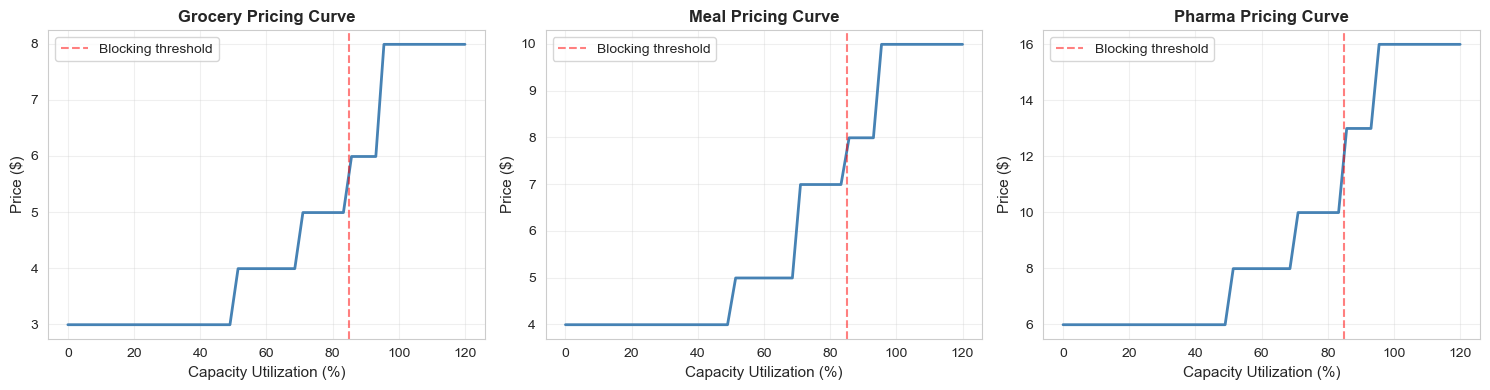

📊 Key Insight: Prices surge sharply above 85% utilization to prevent blocking


In [5]:
# Generate price curves across utilization levels
utilizations = np.linspace(0, 1.2, 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, order_type in enumerate(['Grocery', 'Meal', 'Pharma']):
    prices = [
        model.calculate_price(
            nest_id=5,
            order_type=order_type,
            distance_miles=7.0,
            utilization=util
        )
        for util in utilizations
    ]
    
    ax = axes[idx]
    ax.plot(utilizations * 100, prices, linewidth=2, color='steelblue')
    ax.axvline(x=85, color='red', linestyle='--', alpha=0.5, label='Blocking threshold')
    ax.set_xlabel('Capacity Utilization (%)', fontsize=11)
    ax.set_ylabel('Price ($)', fontsize=11)
    ax.set_title(f'{order_type} Pricing Curve', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print("📊 Key Insight: Prices surge sharply above 85% utilization to prevent blocking")

## Full Pricing Matrix

In [6]:
# Create comprehensive pricing table
utilization_levels = [0.3, 0.5, 0.7, 0.85, 0.95]
order_types = ['Grocery', 'Meal', 'Pharma']
distances = [5, 7, 10]

# Build table
rows = []
for util in utilization_levels:
    for order_type in order_types:
        for distance in distances:
            price = model.calculate_price(
                nest_id=5,
                order_type=order_type,
                distance_miles=distance,
                utilization=util
            )
            rows.append({
                'Utilization': f"{util*100:.0f}%",
                'Order Type': order_type,
                'Distance (mi)': distance,
                'Price': f"${price:.2f}"
            })

pricing_table = pd.DataFrame(rows)

# Pivot for better visualization
print("\nPricing Matrix: Grocery Orders")
print("="*60)
grocery_table = pricing_table[pricing_table['Order Type'] == 'Grocery'].pivot(
    index='Utilization', 
    columns='Distance (mi)', 
    values='Price'
)
print(grocery_table)

print("\nPricing Matrix: Meal Orders")
print("="*60)
meal_table = pricing_table[pricing_table['Order Type'] == 'Meal'].pivot(
    index='Utilization', 
    columns='Distance (mi)', 
    values='Price'
)
print(meal_table)

print("\nPricing Matrix: Pharma Orders")
print("="*60)
pharma_table = pricing_table[pricing_table['Order Type'] == 'Pharma'].pivot(
    index='Utilization', 
    columns='Distance (mi)', 
    values='Price'
)
print(pharma_table)


Pricing Matrix: Grocery Orders
Distance (mi)     5      7      10
Utilization                       
30%            $2.99  $2.99  $2.99
50%            $3.99  $3.99  $3.99
70%            $4.99  $4.99  $4.99
85%            $5.99  $5.99  $6.99
95%            $6.99  $7.99  $7.99

Pricing Matrix: Meal Orders
Distance (mi)     5      7       10
Utilization                        
30%            $3.99  $3.99   $3.99
50%            $4.99  $4.99   $5.99
70%            $5.99  $6.99   $7.99
85%            $7.99  $7.99   $8.99
95%            $8.99  $9.99  $10.99

Pricing Matrix: Pharma Orders
Distance (mi)      5       7       10
Utilization                          
30%             $4.99   $5.99   $5.99
50%             $6.99   $7.99   $8.99
70%             $9.99   $9.99  $10.99
85%            $11.99  $12.99  $13.99
95%            $13.99  $15.99  $16.99


## Why This Model Works

### ✅ Addresses Priority 1: Customer Experience
- **Prevents blocking** by raising prices when capacity approaches limits
- **Price signal throttles demand** before we hit hard capacity constraints
- **Customers never see "unavailable"** - they see a price and can decide

### ✅ Addresses Priority 2: Maximize Profit
- **Captures willingness-to-pay** during peak demand (surge pricing)
- **Premium pricing for inelastic demand** (Pharma can sustain higher prices)
- **Fills capacity during off-peak** with discounted pricing

### ✅ Addresses Priority 3: Asset Utilization
- **Smooths demand curve** by encouraging off-peak usage
- **Reduces idle time** through low off-peak pricing
- **Maximizes deliveries per drone** by optimizing capacity usage

### 🎯 Additional Benefits
- **Transparent**: Every price can be explained ("It's lunch hour and we're at 90% capacity")
- **Tunable**: Thresholds can be adjusted based on business goals
- **Fair**: Prices respond to real capacity constraints, not arbitrary algorithms
- **Competitive**: Stays within market-competitive ranges

## Implementation Roadmap

### Phase 1: Soft Launch (Weeks 1-2)
- Deploy at 2-3 high-blocking hubs (0, 1, 3)
- Monitor blocking rates daily
- A/B test: 50% dynamic pricing, 50% baseline

### Phase 2: Optimization (Weeks 3-4)
- Tune utilization thresholds based on results
- Adjust price caps if needed
- Refine order-type multipliers

### Phase 3: Full Rollout (Week 5+)
- Deploy to all hubs
- Continue monitoring and optimization
- Build dashboard for real-time monitoring

### Success Metrics
1. **Blocking rate**: Target <2% (from current ~8% at problem hubs)
2. **Revenue per session**: Target +10-15% increase
3. **Capacity variance**: Target -20% reduction in hourly variance

## Next Steps

To validate this model with your actual data:

1. **Load your session and pricing data**
2. **Run simulation.py** to compare strategies
3. **Analyze results** to confirm blocking reduction and revenue increase
4. **Tune parameters** if needed based on your specific data patterns

The model is designed to be **simple and interpretable** so you can:
- Explain every pricing decision to executives
- Adjust thresholds based on business priorities
- Debug issues when they arise
- Build stakeholder confidence in the approach